<a href="https://colab.research.google.com/github/MRazaRashid/SolvedMLNotebooks/blob/main/MultiColinearity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use the famous boston dataset and find out if there is multicollinearity or not. If there is multicollinearity try to remove it with help of steps taught in the session.

In [ ]:
url="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
import pandas as pd


df = pd.read_csv(url)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.shape

(506, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In [ ]:
correlation=df.corr()

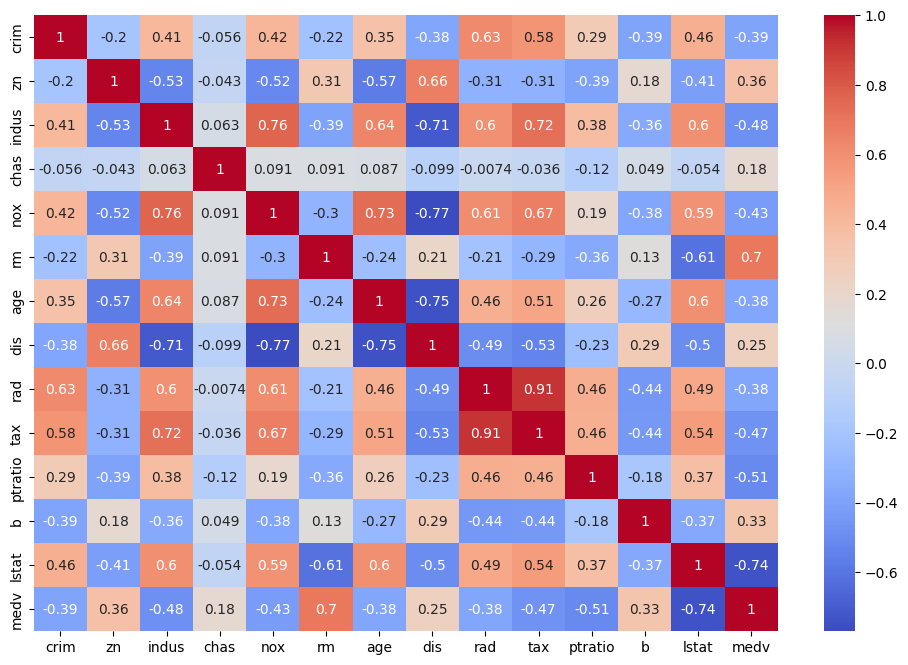

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
print("\nHighly correlated feature pairs (|r| > 0.7):")
corr = df.corr()
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")



Highly correlated feature pairs (|r| > 0.7):
  indus <-> nox: 0.764
  indus <-> dis: -0.708
  indus <-> tax: 0.721
  nox <-> age: 0.731
  nox <-> dis: -0.769
  age <-> dis: -0.748
  rad <-> tax: 0.910
  lstat <-> medv: -0.738


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
t = df.drop("medv", axis=1)
X = pd.DataFrame(scaler.fit_transform(t), columns=t.columns)

Y=df["medv"]

In [ ]:
vif=[]
for i in range (X.shape[-1]):
  vif.append(variance_inflation_factor(X,i))
print(vif)

[np.float64(1.7921915474332395), np.float64(2.298758178749442), np.float64(3.9915964183460297), np.float64(1.0739953275537877), np.float64(4.393719847577495), np.float64(1.933744435783257), np.float64(3.1008255128153372), np.float64(3.95594490637273), np.float64(7.484496335274466), np.float64(9.008553947597061), np.float64(1.7990840492488984), np.float64(1.3485210764063758), np.float64(2.9414910780919348)]


In [ ]:
v=pd.DataFrame({'vif':vif},index=X.columns).T
v

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
vif,1.792192,2.298758,3.991596,1.073995,4.39372,1.933744,3.100826,3.955945,7.484496,9.008554,1.799084,1.348521,2.941491


In [ ]:
v.sort_values(by='vif',axis=1)

,chas,b,crim,ptratio,rm,zn,lstat,age,dis,indus,nox,rad,tax
vif,1.073995,1.348521,1.792192,1.799084,1.933744,2.298758,2.941491,3.100826,3.955945,3.991596,4.39372,7.484496,9.008554


In [ ]:
nx=X.drop('tax',axis=1)
nx.shape

(506, 12)

In [ ]:
nvif=[]
for i in range (nx.shape[1]):
  nvif.append(variance_inflation_factor(nx,i))

In [ ]:
nv=pd.DataFrame({'nvif':nvif},index=nx.columns)
nv.sort_values(by='nvif',ascending=False)

,nvif
nox,4.369271
dis,3.954446
indus,3.226015
age,3.098044
lstat,2.940800
rad,2.837494
zn,2.184240
rm,1.923075
crim,1.791940
ptratio,1.788839


In [ ]:
nv['oldvif']=v.loc['vif']
nv#

,nvif,oldvif
crim,1.791940,1.792192
zn,2.184240,2.298758
indus,3.226015,3.991596
chas,1.058220,1.073995
nox,4.369271,4.393720
rm,1.923075,1.933744
age,3.098044,3.100826
dis,3.954446,3.955945
rad,2.837494,7.484496
ptratio,1.788839,1.799084


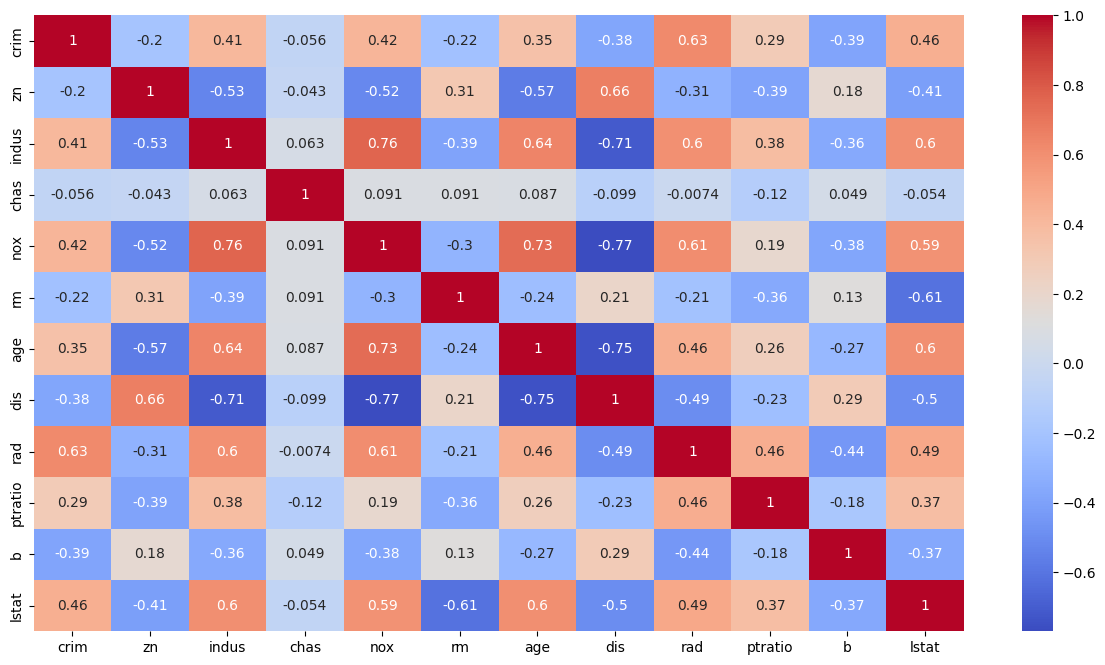

In [ ]:
ncorr=nx.corr()
plt.figure(figsize=(15
                    , 8))
sns.heatmap(
    ncorr,
    annot=True,
    cmap="coolwarm"
)

plt.figure(figsize=(12, 8))